# Project Capstone

## Import Libraries

In [3]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

## Data Wrangling

In [4]:
data = pd.read_csv("./data/data.csv")
data = pd.DataFrame(data)
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
data.fillna(value="None", inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
print("Jumlah duplikasi: ", data.duplicated().sum())

Jumlah duplikasi:  0


In [10]:
dataset = data.drop(columns=['Person ID', 'Occupation', 'Blood Pressure'])
dataset.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,6.1,6,42,6,Overweight,77,4200,None
1,Male,28,6.2,6,60,8,Normal,75,10000,None
2,Male,28,6.2,6,60,8,Normal,75,10000,None
3,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea
4,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea


In [11]:
dataset.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [12]:
label_encoders = {}
for column in dataset.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    dataset[column] = label_encoders[column].fit_transform(dataset[column])

In [13]:
dataset.describe()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.505348,42.184492,7.132086,7.312834,59.171123,5.385027,1.296791,70.165775,6816.844920,1.002674
std,0.500641,8.673133,0.795657,1.196956,20.830804,1.774526,1.431226,4.135676,1617.915679,0.644626
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,0.000000,65.000000,3000.000000,0.000000
25%,0.000000,35.250000,6.400000,6.000000,45.000000,4.000000,0.000000,68.000000,5600.000000,1.000000
50%,1.000000,43.000000,7.200000,7.000000,60.000000,5.000000,0.000000,70.000000,7000.000000,1.000000
75%,1.000000,50.000000,7.800000,8.000000,75.000000,7.000000,3.000000,72.000000,8000.000000,1.000000
max,1.000000,59.000000,8.500000,9.000000,90.000000,8.000000,3.000000,86.000000,10000.000000,2.000000


In [14]:
x = dataset.drop(columns=['Quality of Sleep'])
y = dataset['Quality of Sleep']

In [15]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42)

print("Training data size:", len(x_train))
print("Validation data size:", len(x_val))

print("\nTraining label size:", len(y_train))
print("Validation label size:", len(y_val))

Training data size: 261
Validation data size: 113

Training label size: 261
Validation label size: 113


In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

## Machine Learning

In [17]:
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs['val_mae'] <= 0.1 and epoch >= 250:
            print("Early stopping triggered at epoch ", epoch, " because validation MAE is less than 0.1")
            self.model.stop_training = True

In [18]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

In [22]:
history = model.fit(x_train_scaled, y_train,
                    epochs=1000,
                    validation_data=(x_val_scaled, y_val),
                    batch_size=32,
                    callbacks=[CustomCallback()]
)

Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0013 - mae: 0.0231 - val_loss: 0.1050 - val_mae: 0.1043
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - mae: 0.0250 - val_loss: 0.1040 - val_mae: 0.1216
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - mae: 0.0427 - val_loss: 0.1096 - val_mae: 0.1414
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0550 - val_loss: 0.1048 - val_mae: 0.1179
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - mae: 0.0396 - val_loss: 0.1038 - val_mae: 0.1124
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - mae: 0.0345 - val_loss: 0.1061 - val_mae: 0.1155
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - mae: 0.0333 - val_loss: 0.1053 - val_mae: 0.1064
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - mae: 0.0272 - val_loss: 0.1077 - val_mae: 0.1090
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae:

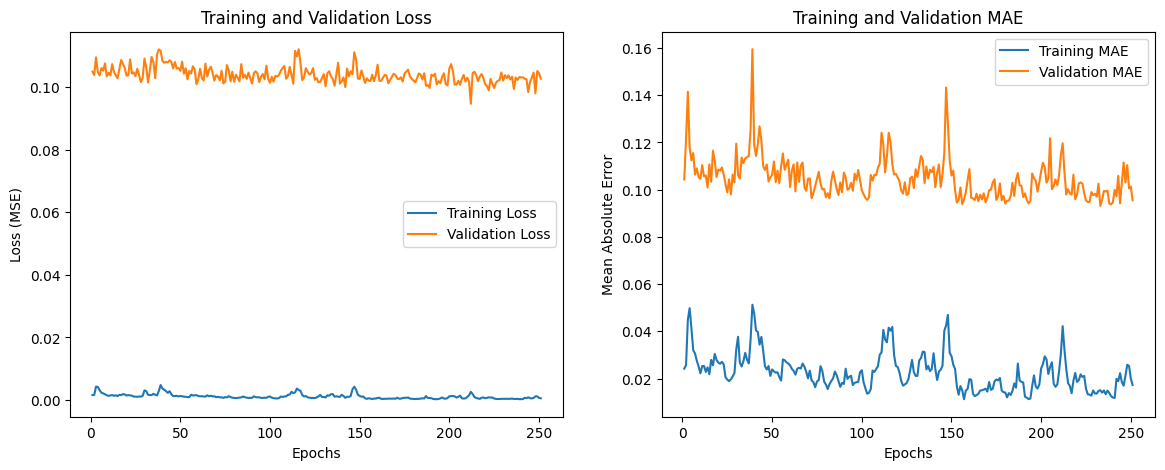

In [23]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

# Create a range for epochs
epochs = range(1, len(loss) + 1)

# Plot the loss over epochs
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()

In [24]:
predictions = model.predict(x_val_scaled)

print("Beberapa prediksi pertama:")
for i in range(10):
    print(f"Prediksi: {predictions[i][0]:.2f}, Nilai aktual: {y_val.iloc[i]:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Beberapa prediksi pertama:
Prediksi: 9.00, Nilai aktual: 9.00
Prediksi: 6.00, Nilai aktual: 6.00
Prediksi: 5.99, Nilai aktual: 6.00
Prediksi: 9.00, Nilai aktual: 9.00
Prediksi: 5.99, Nilai aktual: 6.00
Prediksi: 6.02, Nilai aktual: 6.00
Prediksi: 5.98, Nilai aktual: 6.00
Prediksi: 8.02, Nilai aktual: 8.00
Prediksi: 8.99, Nilai aktual: 9.00
Prediksi: 8.00, Nilai aktual: 8.00


In [ ]:
# model.save('model.h5')

## Compare Model

In [35]:
loaded_model = tf.keras.models.load_model('model.h5')

In [36]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,755 (10.77 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [38]:
predictions = loaded_model.predict(x_val_scaled)

print("Beberapa prediksi pertama:")
for i in range(5):
    print(f"Prediksi: {predictions[i][0]:.2f}, Nilai aktual: {y_val.iloc[i]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Beberapa prediksi pertama:
Prediksi: 9.00, Nilai aktual: 9.00
Prediksi: 6.00, Nilai aktual: 6.00
Prediksi: 5.99, Nilai aktual: 6.00
Prediksi: 9.00, Nilai aktual: 9.00
Prediksi: 5.99, Nilai aktual: 6.00


## User Input (Error)

In [ ]:
gender = input("Gender (Male/Female): ")
age = int(input("Age: "))
sleep_duration = float(input("Sleep Duration (Per hours): "))
physical_activity_level = int(input("Physical Activity Level (Per minutes): "))
stress_level = int(input("Stress Level (scale 1-10): "))
bmi_category = input("BMI Category (Normal Weight, Normal, Overweight, Obese): ")
heart_rate = int(input("Heart Rate (BPM): "))
daily_steps = int(input("Daily Steps: "))
sleep_disorder = input("Sleep Disorder (None, Sleep Apnea, Insomnia): ")

In [ ]:
data_input = {
    "Gender": gender,
    "Age": age,
    "Sleep Duration": sleep_duration,
    "Physical Activity Level": physical_activity_level,
    "Stress Level": stress_level,
    "BMI Category": bmi_category,
    "Heart Rate": heart_rate,
    "Daily Steps": daily_steps, 
    "Sleep Disorder": sleep_disorder
}

data_user = pd.DataFrame([data_input])
dataset = pd.concat([dataset, data_user], ignore_index=True)

In [ ]:
# Data Encoding
for column in data_user.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    data_user[column] = label_encoders[column].fit_transform(data_user[column])
    
x_input_scaled = scaler.transform(x_val)

print(x_input_scaled[-1])

In [ ]:
dataset.tail()

In [ ]:
predictions = loaded_model.predict(x_input_scaled[-1].reshape(1, -1))
print(f"Prediksi: {predictions[0][0]:.2f}")